In [1]:
# Importing necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Loading the Dataset

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [4]:
print("shape:", df.shape)

shape: (7043, 21)


# INSIGHT
7,043 rows, 21 columns. One row per customer.

# Cleaning the dataset

In [5]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

df = df.drop(columns=["customerID"])  # just an ID, no predictive value

# TotalCharges is stored as text because some rows have blank strings
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Missing values in TotalCharges:", df["TotalCharges"].isna().sum())
df["TotalCharges"] = df["TotalCharges"].fillna(0)

df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

Duplicate rows: 0
Missing values in TotalCharges: 11


# Exploratory Data Analysis (EDA)

In [6]:
churn_rate = df["Churn"].mean() * 100
print(f"Overall churn rate: {churn_rate:.2f}%")

print(df.groupby("Contract")["Churn"].mean().sort_values(ascending=False) * 100)
print(df.groupby("InternetService")["Churn"].mean().sort_values(ascending=False) * 100)

Overall churn rate: 26.54%
Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64
InternetService
Fiber optic    41.892765
DSL            18.959108
No              7.404980
Name: Churn, dtype: float64


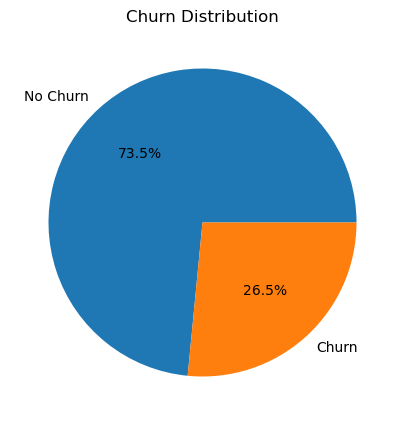

In [13]:
# Churn Distrinution

plt.figure(figsize=(5,5))
df["Churn"].value_counts().plot(kind="pie", labels=["No Churn","Churn"], autopct="%1.1f%%")
plt.title("Churn Distribution")
plt.ylabel("")
plt.savefig("churn_pie.png")
plt.show()

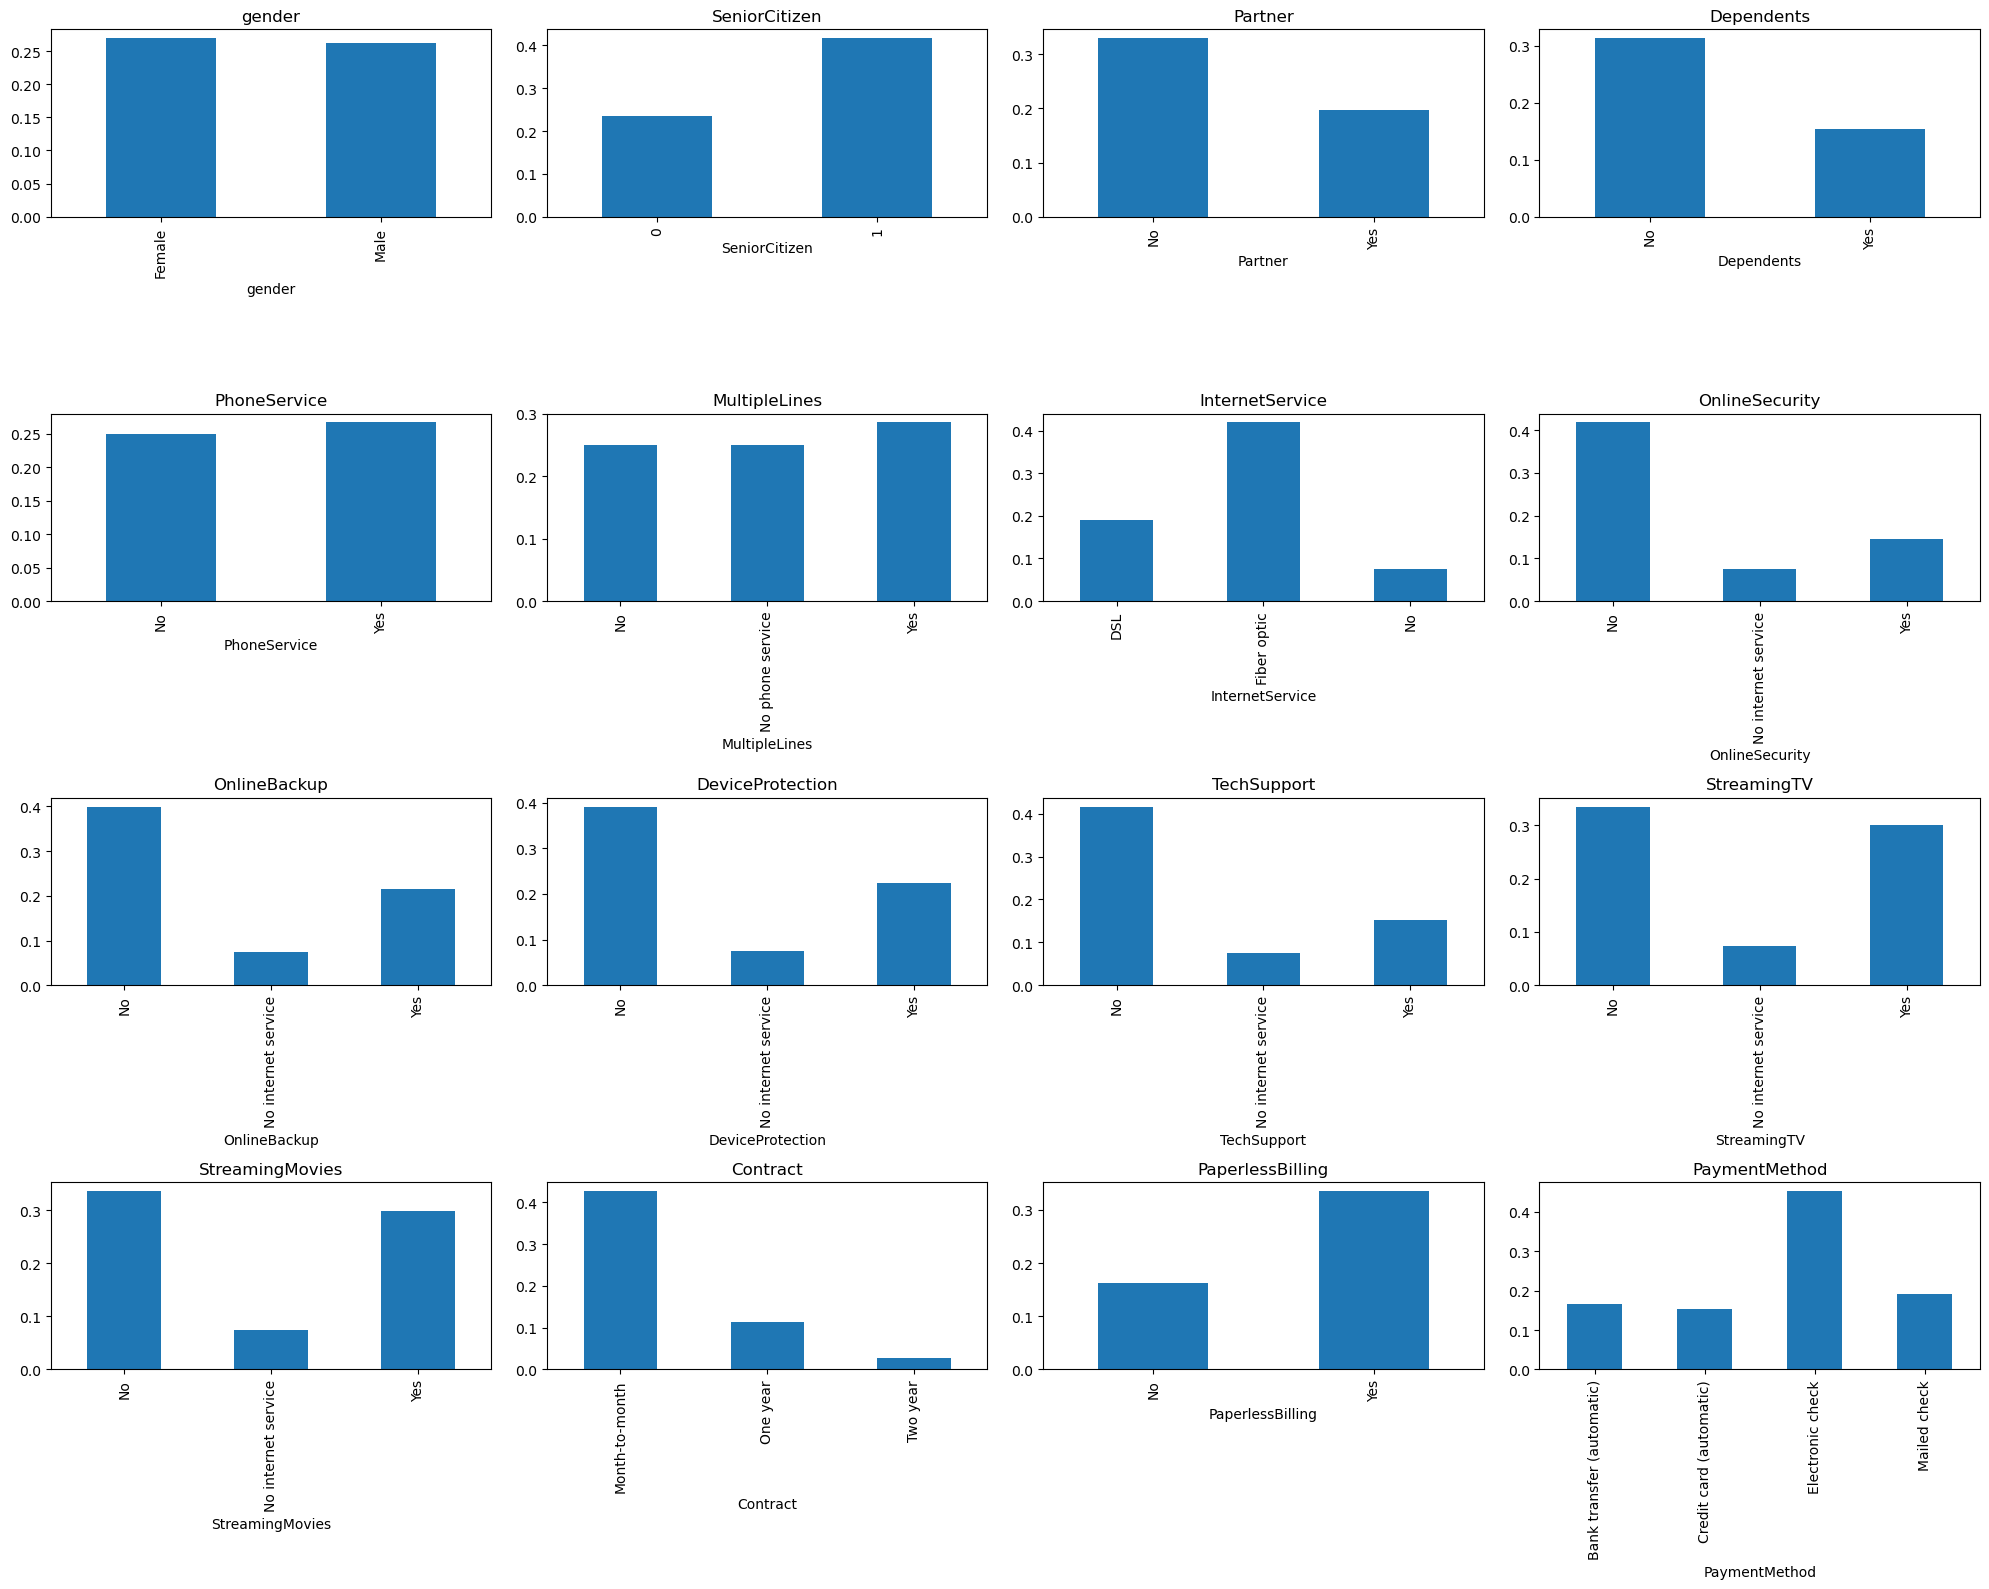

In [11]:
# CHurn rate by categorical columns

cat_cols = ["gender","SeniorCitizen","Partner","Dependents","PhoneService",
            "MultipleLines","InternetService","OnlineSecurity","OnlineBackup",
            "DeviceProtection","TechSupport","StreamingTV","StreamingMovies",
            "Contract","PaperlessBilling","PaymentMethod"]

fig, axes = plt.subplots(4, 4, figsize=(20,16))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    df.groupby(col)["Churn"].mean().plot(kind="bar", ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.savefig("churn_by_category.png")
plt.show()

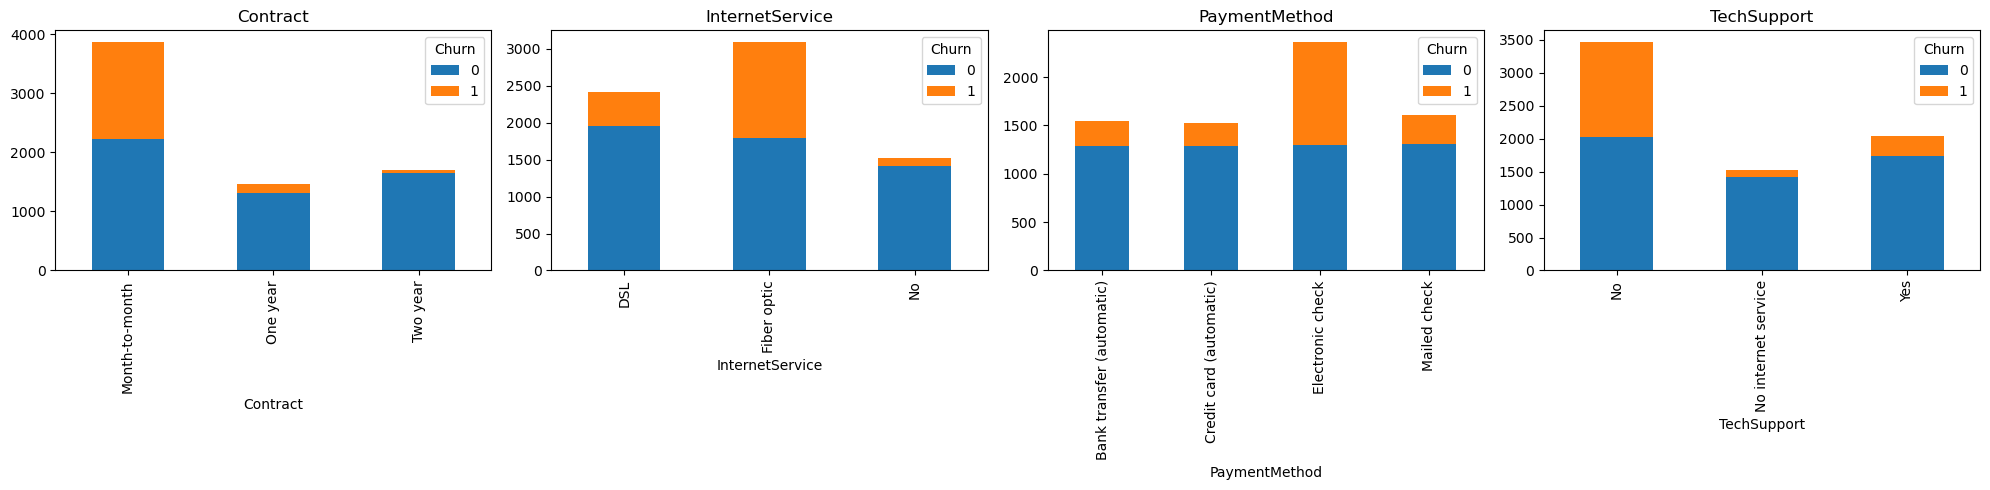

In [12]:
# Customer count by churn

key_cols = ["Contract","InternetService","PaymentMethod","TechSupport"]
fig, axes = plt.subplots(1, 4, figsize=(20,5))

for i, col in enumerate(key_cols):
    pd.crosstab(df[col], df["Churn"]).plot(kind="bar", stacked=True, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.savefig("churn_counts.png")
plt.show()

# Feature Engineering


In [14]:
df["tenure_group"] = pd.cut(
    df["tenure"], bins=[-1, 12, 24, 48, 60, 1000],
    labels=["0-1yr", "1-2yr", "2-4yr", "4-5yr", "5yr+"]
)

service_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                 "TechSupport", "StreamingTV", "StreamingMovies"]
df["num_services"] = (df[service_cols] == "Yes").sum(axis=1)

df["avg_monthly_spend"] = df["TotalCharges"] / df["tenure"].replace(0, 1)

df["no_support_services"] = ((df["OnlineSecurity"] == "No") & (df["TechSupport"] == "No")).astype(int)

In [15]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,num_services,avg_monthly_spend,no_support_services
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-1yr,1,29.850000,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,One year,No,Mailed check,56.95,1889.50,0,2-4yr,2,55.573529,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-1yr,2,54.075000,0
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,One year,No,Bank transfer (automatic),42.30,1840.75,0,2-4yr,3,40.905556,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-1yr,0,75.825000,1


# Preprocessing + feature selection

In [16]:
target = df["Churn"]
features = df.drop(columns=["Churn"])

cat_cols = features.select_dtypes(include=["object", "category"]).columns.tolist()
features = pd.get_dummies(features, columns=cat_cols, drop_first=True)

# TotalCharges ≈ tenure * MonthlyCharges — redundant, drop it to avoid
# multicollinearity (avg_monthly_spend already captures the ratio version)
features = features.drop(columns=["TotalCharges"])

print("Final feature count:", features.shape[1])

Final feature count: 36


# Train Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, stratify=target, random_state=42
)

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

# SMOTE is applied here — after the split, and only to X_train/y_train.
# X_test stays untouched, so it's still a real, honest sample of the world.
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f"After SMOTE - train churn rate: {y_train_res.mean():.2%}, rows: {X_train_res.shape[0]}")

After SMOTE - train churn rate: 50.00%, rows: 8278


In [18]:
# Model Comparison

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

results = []
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "ROC_AUC": roc_auc_score(y_test, proba),
    })

results_df = pd.DataFrame(results).sort_values("ROC_AUC", ascending=False)
print(results_df.to_string(index=False))

              Model  Accuracy  Precision   Recall       F1  ROC_AUC
  Gradient Boosting  0.779986   0.571429 0.684492 0.622871 0.841564
Logistic Regression  0.738822   0.505190 0.780749 0.613445 0.840471
      Random Forest  0.773598   0.577031 0.550802 0.563611 0.820181


# Hyperparameter Tuning

In [20]:
grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    {"n_estimators": [100, 200], "learning_rate": [0.05, 0.1], "max_depth": [2, 3, 4]},
    scoring="roc_auc", cv=5, n_jobs=-1
)
grid.fit(X_train_res, y_train_res)
print("Best params:", grid.best_params_)
print(f"Best CV ROC-AUC (on resampled train): {grid.best_score_:.4f}")

best_model = grid.best_estimator_

Best params: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}
Best CV ROC-AUC (on resampled train): 0.9389


# Final Testing on the untouched test set

In [21]:
preds = best_model.predict(X_test)
proba = best_model.predict_proba(X_test)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, preds), 4))
print("Precision:", round(precision_score(y_test, preds), 4))
print("Recall   :", round(recall_score(y_test, preds), 4))
print("F1       :", round(f1_score(y_test, preds), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, proba), 4))

cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring="roc_auc")
print(f"5-fold CV ROC-AUC on real train data: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

Accuracy : 0.7842
Precision: 0.5946
Recall   : 0.5882
F1       : 0.5914
ROC-AUC  : 0.8373
5-fold CV ROC-AUC on real train data: 0.8343 +/- 0.0137


In [22]:
# Feature Importance

importances = pd.Series(best_model.feature_importances_, index=features.columns)
top_features = importances.sort_values(ascending=False).head(12)
print(top_features.round(4))

no_support_services               0.2583
tenure                            0.1296
Contract_Two year                 0.0880
Contract_One year                 0.0701
PaymentMethod_Electronic check    0.0682
InternetService_Fiber optic       0.0608
PaperlessBilling_Yes              0.0481
avg_monthly_spend                 0.0451
MonthlyCharges                    0.0281
Dependents_Yes                    0.0244
OnlineBackup_Yes                  0.0239
Partner_Yes                       0.0223
dtype: float64
